In [118]:
from sklearn import linear_model
import sys
from sklearn import linear_model
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pyreadr 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f
from scipy.stats import chi2
import math
from scipy.stats import gmean
import re


In [119]:
# Step 2: DATA COLLECTION

df_combustion = pd.read_json("./data_raw/germany_3.json")
df_ev = pd.read_json("data_raw/germany_3_electric.json")
df_ev['fuel'] = 'Electric'
df_plugin = pd.read_json("data_raw/GE_plugin_200_items.json")
df_plugin['fuel'] = 'Plug-in Hybrid'
df_hybrid = pd.read_json('data_raw/GE_hybrid_200_items.json')
df_hybrid['fuel'] = 'Hybrid'


# filter out: old, very low mileage cars (over 10 years, under 50.000 km)

def clean_fuel_new(fuel):
    
    fuel = fuel.lower()

    if 'hybrid' in fuel:
        return 'Hybrid'
    elif 'diesel' in fuel:
        return 'Diesel'
    elif 'electric' in fuel:
        return 'Electric'
    elif 'petrol' in fuel:
        return 'Petrol'
    
df_combustion['fuel_raw'] = df_combustion['attributes'].apply(lambda x: x.get('Fuel'))

df_combustion['fuel'] = df_combustion['fuel_raw'].apply(clean_fuel_new)
# remove empty-value-fuel cars -> leftover electric cars from original sample
# df = df.dropna(subset=['fuel'])




df = pd.concat([df_plugin, df_combustion, df_hybrid, df_ev], ignore_index=True)

df
### required attributes: price Y, km Y , year_of_prod Y, age Y, fuel_type, vehicle type
df['country'] = 'GER'
df['price'] = df['price'].apply(lambda x: x['total']['amount'])


df['km'] = df['attributes'].apply(lambda x: int(re.sub(r'\D', '', x.get('Mileage'))))


df['first_reg'] = df['attributes'].apply(
    lambda x: round(
        int(x.get('First Registration').split('/')[1]) +
        (int(x.get('First Registration').split('/')[0]) - 0.5) / 12,
        2
    )
)

df['age'] = round(2026 - df['first_reg'],1)


df['transmission'] = df['attributes'].apply(lambda x: x.get('Transmission'))

# df

df

,title,previewImage,segment,category,brand,model,url,price,createdDate,modifiedDate,...,sellerId,priceRating,dealerDetails,fuel,fuel_raw,country,km,first_reg,age,transmission
0,Mercedes-Benz E 300 e*Navi*360°Cam*SitzHZ*Ambi...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,Mercedes-Benz,E 300,https://suchen.mobile.de/fahrzeuge/details.htm...,28490.0,2025-11-19T16:08:34.000Z,2026-03-17T18:54:26.000Z,...,3495703,"{'rating': 'Fair price', 'priceRanges': {'Very...","{'id': 3495703, 'name': 'Auto Frank & Tan GmbH...",Plug-in Hybrid,NaN,GER,107000,2019.71,6.3,Automatic
1,BMW 330 e Sport Line*Laser*Head-Up*Kamera*Ha/K...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,BMW,330,https://suchen.mobile.de/fahrzeuge/details.htm...,28950.0,2026-02-09T17:52:10.000Z,2026-03-17T18:29:13.000Z,...,16578055,"{'rating': 'Fair price', 'priceRanges': {'Very...","{'id': 16578055, 'name': 'Auto Scheib VSV GbR'...",Plug-in Hybrid,NaN,GER,94400,2020.21,5.8,Automatic
2,BMW 330e iPerformance Advantage LED Tempomat L...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,BMW,330,https://suchen.mobile.de/fahrzeuge/details.htm...,17990.0,2026-02-07T05:26:30.000Z,2026-03-23T05:28:02.000Z,...,33726553,"{'rating': 'Good price', 'priceRanges': {'Very...","{'id': 33726553, 'name': 'Autoland NL Hannover...",Plug-in Hybrid,NaN,GER,106200,2016.46,9.5,Automatic
3,Volkswagen PASSAT Variant GTE 1.4 TSI 218PS DS...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,EstateCar,Volkswagen,Passat,https://suchen.mobile.de/fahrzeuge/details.htm...,18999.0,2025-09-28T18:06:01.000Z,2026-03-23T02:01:49.000Z,...,9246884,"{'rating': 'Good price', 'priceRanges': {'Very...","{'id': 9246884, 'name': 'Autohaus Klann GmbH',...",Plug-in Hybrid,NaN,GER,99269,2017.29,8.7,Automatic
4,Volkswagen Golf GTE 1.4 TSI Plug-in-Hybrid +AC...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,Volkswagen,Golf,https://suchen.mobile.de/fahrzeuge/details.htm...,18945.0,2025-12-30T10:42:34.000Z,2026-03-17T19:15:43.000Z,...,480097,"{'rating': 'Good price', 'priceRanges': {'Very...","{'id': 480097, 'name': 'Auto Gorges GmbH', 'se...",Plug-in Hybrid,NaN,GER,76306,2018.46,7.5,Automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2436,Volkswagen ID.3 Pro S NAVI W-Pumpe LED 77kWh K...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,Volkswagen,ID.3,https://suchen.mobile.de/fahrzeuge/details.htm...,22870.0,2026-03-15T18:00:41.000Z,2026-03-23T05:28:41.000Z,...,459388,"{'rating': 'Fair price', 'priceRanges': {'Very...","{'id': 459388, 'name': 'Volkswagen Automobile ...",Electric,NaN,GER,95100,2023.12,2.9,Automatic
2437,BMW i3 S Laden Vollleder*DAB*Navi*LED*Kamera*1...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,BMW,i3,https://suchen.mobile.de/fahrzeuge/details.htm...,14890.0,2022-11-15T14:55:35.000Z,2026-03-17T15:21:53.000Z,...,452504,"{'rating': 'Good price', 'priceRanges': {'Very...","{'id': 452504, 'name': 'Automarkt-Immelborn Gm...",Electric,NaN,GER,49983,2018.71,7.3,Automatic
2438,BMW i3 S Laden Vollleder*Navi*Led*Kamera*19*Pa...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,BMW,i3,https://suchen.mobile.de/fahrzeuge/details.htm...,14950.0,2022-11-15T14:24:15.000Z,2026-03-17T15:21:52.000Z,...,452504,"{'rating': 'Good price', 'priceRanges': {'Very...","{'id': 452504, 'name': 'Automarkt-Immelborn Gm...",Electric,NaN,GER,49971,2018.71,7.3,Automatic
2439,Volkswagen ID.3 Pure Performance 110 kW Navi+L...,https://img.classistatic.de/api/v1/mo-prod/ima...,Car,Limousine,Volkswagen,ID.3,https://suchen.mobile.de/fahrzeuge/details.htm...,17890.0,2026-03-02T15:04:51.000Z,2026-03-23T01:39:12.000Z,...,471055,"{'rating': 'Fair price', 'priceRanges': {'Very...","{'id': 471055, 'name': 'Karl Thiel GmbH & Co.'...",Electric,NaN,GER,72300,2021.96,4.0,Automatic


Text(0.5, 1.0, 'germany')

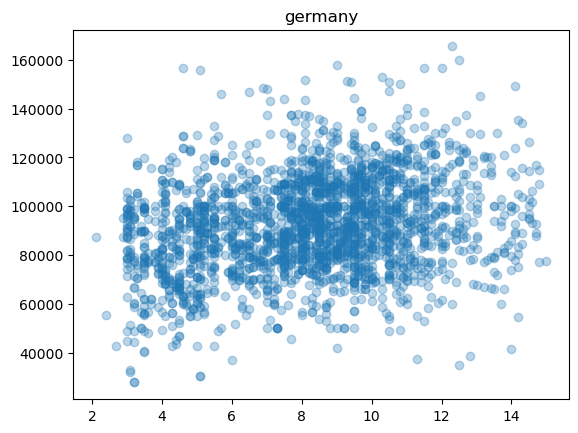

In [120]:
# Step 3: DATA PREPARATION

plt.scatter(df['age'],df['km'],alpha=0.3)
plt.title('germany')

In [121]:
df = df[~((df['age'] > 10) & (df['km'] < 50000))]



In [122]:
df.to_json('GE_prepared_data')

In [123]:
# data overview

print(df['fuel'].value_counts())


fuel
Petrol            1572
Diesel             262
Electric           201
Plug-in Hybrid     200
Hybrid             200
Name: count, dtype: int64
